# Fracture Multi-Source — Construction du Dataset de Recherche

Ce notebook construit un dataset unifie a partir de 5 sources Roboflow et du dataset FracAtlas (Kaggle).  
Le dataset final contient 7 classes anatomiques : elbow, humerus, finger, forearm, femur, normal, leg.  
Le resultat est sauvegarde sur Google Drive au format YOLO.

| ID | Classe | Source |
|----|--------|--------|
| 0 | fracture_elbow | Roboflow |
| 1 | fracture_humerus | Roboflow |
| 2 | fracture_finger | Roboflow |
| 3 | fracture_forearm | Roboflow |
| 4 | fracture_femur | Roboflow |
| 5 | normal | FracAtlas (Kaggle) |
| 6 | fracture_leg | FracAtlas (Kaggle) |

## Etape 1 — Installation des dependances

In [1]:
!pip install roboflow ultralytics pyyaml matplotlib pillow kaggle -q

import os
import yaml
import glob
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from roboflow import Roboflow
from collections import defaultdict, Counter

print('Installation OK')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 91.8 MB/s eta 0:00:00
Installation OK


## Etape 2 — Configuration des sources Roboflow

In [ ]:
API_KEY = "raison_de_sécurité_j'ai_masqué ma clé api roboflow"  

SOURCES = [
    {
        "name": "Elbow Fracture",
        "workspace": "swanand-s-workspace",
        "project": "fracture-elbow-detection",
        "version": 1,
        "short": "elbow"
    },
    {
        "name": "Humerus Fracture",
        "workspace": "new-workspace-ozkjr",
        "project": "humerus-ghx7b",
        "version": 1,
        "short": "humerus"
    },
    {
        "name": "Finger Fracture",
        "workspace": "landy-aw2jb",
        "project": "fracture-ov5p1",
        "version": 1,
        "short": "finger"
    },
    {
        "name": "Forearm Fracture",
        "workspace": "symbi-sm5ho",
        "project": "fracture-xmscd",
        "version": 1,
        "short": "forearm"
    },
    {
        "name": "Femur Fracture",
        "workspace": "ebrucans-workspace",
        "project": "femur-fracture",
        "version": 1,
        "short": "femur"
    }
]

# Classe unifiee finale par source
SOURCE_TO_CLASS = {
    "elbow":   0,
    "humerus": 1,
    "finger":  2,
    "forearm": 3,
    "femur":   4
}

# Classes FracAtlas
FRACATLAS_NORMAL_CLASS = 5
FRACATLAS_LEG_CLASS    = 6

CLASS_NAMES = [
    "fracture_elbow",
    "fracture_humerus",
    "fracture_finger",
    "fracture_forearm",
    "fracture_femur",
    "normal",
    "fracture_leg"
]

print(f'Sources configurees : {len(SOURCES)} datasets Roboflow + FracAtlas')

Sources configurees : 5 datasets Roboflow + FracAtlas


## Etape 3 — Telechargement des datasets Roboflow

In [3]:
BASE_DIR = "/content/dataset_raw"
os.makedirs(BASE_DIR, exist_ok=True)

rf = Roboflow(api_key=API_KEY)

downloaded = {}
failed = []

for src in SOURCES:
    print(f"\nTelechargement : {src['name']}")
    dest = os.path.join(BASE_DIR, src['short'])
    try:
        project = rf.workspace(src['workspace']).project(src['project'])
        dataset = project.version(src['version']).download("yolov8", location=dest)
        downloaded[src['short']] = dataset.location
        print(f"    OK : {dataset.location}")
    except Exception as e:
        print(f"    ERREUR : {e}")
        failed.append(src['name'])

print("\n====================")
print(f"OK     : {len(downloaded)}")
print(f"FAILED : {len(failed)}")
if failed:
    print("Sources echouees:", failed)


Telechargement : Elbow Fracture
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/dataset_raw/elbow in yolov8:: 100%|██████████| 773/773 [00:00<00:00, 8887.72it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
    OK : /content/dataset_raw/elbow

Telechargement : Humerus Fracture
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/dataset_raw/humerus in yolov8:: 100%|██████████| 2905/2905 [00:00<00:00, 5015.56it/s]

    OK : /content/dataset_raw/humerus

Telechargement : Finger Fracture
loading Roboflow workspace...


...


Extracting Dataset Version Zip to /content/dataset_raw/forearm in yolov8:: 100%|██████████| 978/978 [00:00<00:00, 6359.59it/s]

    OK : /content/dataset_raw/forearm

Telechargement : Femur Fracture
loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to /content/dataset_raw/femur in yolov8:: 100%|██████████| 533/533 [00:00<00:00, 6767.55it/s]

    OK : /content/dataset_raw/femur

OK     : 5
FAILED : 0


## Etape 4 — Analyse des labels et classes par source

In [4]:
def analyze_dataset(location, short_name):
    info = {'name': short_name, 'location': location}
    yaml_path = os.path.join(location, 'data.yaml')
    with open(yaml_path) as f:
        cfg = yaml.safe_load(f)
    info['classes'] = cfg.get('names', [])
    info['nc']      = cfg.get('nc', 0)
    for split in ['train', 'valid', 'test']:
        img_dir = os.path.join(location, split, 'images')
        info[f'{split}_imgs'] = len(os.listdir(img_dir)) if os.path.exists(img_dir) else 0
    info['total_imgs'] = info['train_imgs'] + info['valid_imgs'] + info['test_imgs']
    label_dir = os.path.join(location, 'train', 'labels')
    class_counts = Counter()
    boxes_per_img = []
    all_wh = []
    if os.path.exists(label_dir):
        for lf in os.listdir(label_dir):
            lpath = os.path.join(label_dir, lf)
            with open(lpath) as f:
                lines = [l.strip() for l in f if l.strip()]
            boxes_per_img.append(len(lines))
            for line in lines:
                parts = line.split()
                if len(parts) >= 5:
                    class_counts[int(parts[0])] += 1
                    all_wh.append((float(parts[3]), float(parts[4])))
    info['class_counts']  = dict(class_counts)
    info['total_annot']   = sum(class_counts.values())
    info['avg_boxes']     = round(np.mean(boxes_per_img), 2) if boxes_per_img else 0
    info['avg_box_size']  = round(np.mean([w * h for w, h in all_wh]), 4) if all_wh else 0
    info['boxes_per_img'] = boxes_per_img
    info['all_wh']        = all_wh
    return info

analyses = {}
for src in SOURCES:
    short = src['short']
    if short in downloaded:
        print(f"Analyse : {src['name']}...")
        analyses[short] = analyze_dataset(downloaded[short], src['name'])
print('\nAnalyse terminee')

Analyse : Elbow Fracture...
Analyse : Humerus Fracture...
Analyse : Finger Fracture...
Analyse : Forearm Fracture...
Analyse : Femur Fracture...

Analyse terminee


## Etape 5 — Tableau recapitulatif des classes

In [5]:
print("=" * 85)
print(f"{'SOURCE':<28} {'NB CLS':<8} {'CLASSES':<30} {'IMAGES':<8} {'ANNOT.'}")
print("=" * 85)
for src in SOURCES:
    short = src['short']
    if short not in analyses:
        print(f"{src['name']:<28}  Non telecharge")
        continue
    a = analyses[short]
    cls_str = str(a['classes'])[:28]
    print(f"{a['name']:<28} {a['nc']:<8} {cls_str:<30} {a['total_imgs']:<8} {a['total_annot']}")
print("=" * 85)

print("\nDETAIL COMPLET PAR SOURCE")
for src in SOURCES:
    short = src['short']
    if short not in analyses:
        continue
    a = analyses[short]
    print(f"\n{a['name'].upper()}")
    print(f"   Classes      : {a['classes']}")
    print(f"   Nb classes   : {a['nc']}")
    print(f"   Train imgs   : {a['train_imgs']}")
    print(f"   Valid imgs   : {a['valid_imgs']}")
    print(f"   Test imgs    : {a['test_imgs']}")
    print(f"   Total imgs   : {a['total_imgs']}")
    print(f"   Annotations  : {a['total_annot']}")
    print(f"   Moy box/img  : {a['avg_boxes']}")
    print(f"   Distrib cls  : {a['class_counts']}")

SOURCE                       NB CLS   CLASSES                        IMAGES   ANNOT.
Elbow Fracture               42       ['AP elbow Dislocation', 'AP   384      363
Humerus Fracture             4        ['oblique', 'segmental', 'sp   1450     1354
Finger Fracture              1        ['Fracture Detection - v1 20   22557    24264
Forearm Fracture             4        ['-', '1', '1-', 'fracture']   483      480
Femur Fracture               2        ['fructure1', 'fructure2']     264      198

DETAIL COMPLET PAR SOURCE

ELBOW FRACTURE
   Classes      : ['AP elbow Dislocation', 'AP elbow Dislocation fracture', 'Coronoid FRACTURE', 'Distal humeral fracture', 'Humerus-epiphysis', 'Lateral elbow fracture Dislocation', 'Lateral epicondyle', 'Lateral humeras medial condyle', 'Lateral meddle pediatric epicondrials', 'Left Elbow Arthritis', 'MO of elbow', 'Metal Plate', 'Myositis Ossificans of elbow', 'Osteochondroma', 'Radial-Head Fracture', 'Radial-Head epiphysis', 'Radial-shaft Fracture', '

## Etape 6 — Toutes les classes brutes (lire avant etape 7)

In [6]:
print("=" * 60)
print("TOUTES LES CLASSES PAR SOURCE")
print("=" * 60)
all_unique = set()
for src in SOURCES:
    short = src['short']
    if short not in analyses:
        continue
    a = analyses[short]
    print(f"\n{src['name'].upper()}")
    for i, cls in enumerate(a['classes']):
        cnt = a['class_counts'].get(i, 0)
        print(f"   [{i}] {cls:<35} -> {cnt} annotations")
        all_unique.add(cls.lower().strip())
print(f"\nClasses uniques (Roboflow) : {len(all_unique)}")
print(sorted(all_unique))

TOUTES LES CLASSES PAR SOURCE

ELBOW FRACTURE
   [0] AP elbow Dislocation                -> 0 annotations
   [1] AP elbow Dislocation fracture       -> 1 annotations
   [2] Coronoid FRACTURE                   -> 1 annotations
   [3] Distal humeral fracture             -> 0 annotations
   [4] Humerus-epiphysis                   -> 1 annotations
   [5] Lateral elbow fracture Dislocation  -> 3 annotations
   [6] Lateral epicondyle                  -> 3 annotations
   [7] Lateral humeras medial condyle      -> 0 annotations
   [8] Lateral meddle pediatric epicondrials -> 0 annotations
   [9] Left Elbow Arthritis                -> 1 annotations
   [10] MO of elbow                         -> 2 annotations
   [11] Metal Plate                         -> 31 annotations
   [12] Myositis Ossificans of elbow        -> 1 annotations
   [13] Osteochondroma                      -> 1 annotations
   [14] Radial-Head Fracture                -> 4 annotations
   [15] Radial-Head epiphysis               ->

## Etape 7 — Nettoyage et remapping des labels Roboflow

Toutes les sous-classes de fracture sont unifiees vers la classe anatomique correspondante.  
Le remapping se fait en une seule passe par dataset pour eviter les ecrasements.

In [7]:
def read_labels(path):
    with open(path, "r") as f:
        return [l.strip() for l in f if l.strip()]

def write_labels(path, lines):
    with open(path, "w") as f:
        f.write("\n".join(lines))


def remap_dataset_by_name(folder, class_name_mapping, unified_class_id):
    """
    Relit data.yaml pour recuperer les noms de classes,
    filtre les annotations dont le nom mappe vers 'fracture',
    et ecrit l'identifiant unifie unified_class_id.

    class_name_mapping : dict {nom_original (str) -> 'fracture' ou None}
    unified_class_id   : int, ID de la classe dans le dataset final
    """
    yaml_path = os.path.join(folder, "data.yaml")
    with open(yaml_path) as f:
        cfg = yaml.safe_load(f)
    class_names = cfg.get("names", [])

    # Construire le mapping id -> unified_class_id ou None
    id_map = {}
    for idx, name in enumerate(class_names):
        mapped = class_name_mapping.get(name.lower().strip())
        id_map[idx] = unified_class_id if mapped == "fracture" else None

    splits = ["train", "valid", "test"]
    total_kept = 0
    total_dropped = 0

    for split in splits:
        label_dir = os.path.join(folder, split, "labels")
        if not os.path.exists(label_dir):
            continue
        for file in glob.glob(label_dir + "/*.txt"):
            lines = read_labels(file)
            new_lines = []
            for line in lines:
                parts = line.split()
                if len(parts) < 5:
                    continue
                src_id = int(parts[0])
                dst_id = id_map.get(src_id)
                if dst_id is not None:
                    new_lines.append(f"{dst_id} " + " ".join(parts[1:]))
                    total_kept += 1
                else:
                    total_dropped += 1
            write_labels(file, new_lines)

    print(f"   Annotations conservees : {total_kept}")
    print(f"   Annotations supprimees : {total_dropped}")


print("Fonctions de remapping definies")

Fonctions de remapping definies


In [8]:
# --- ELBOW ---
print("\nELBOW")
ELBOW_MAPPING = {
    "coronoid fracture":                                        "fracture",
    "distal humeral fracture":                                  "fracture",
    "radial-head fracture":                                     "fracture",
    "radial-shaft fracture":                                    "fracture",
    "radial-shaft fracture with hypertrophic non-union":        "fracture",
    "supra condyle fracture":                                   "fracture",
    "ulna-shaft fracture":                                      "fracture",
    "fracture":                                                 "fracture",
    "medial epicondyle":                                        "fracture",
    "medial epi-condyle fracture":                              "fracture",
    "olecranon fracture in situ":                               "fracture",
    "olecranone process fracture":                              "fracture",
    "fracture with implant":                                    "fracture",
    "op-c-o radial-head fracture right side with implant in situ": "fracture",
    "elbow dislocation":                                        "fracture",
    "ap elbow dislocation":                                     "fracture",
    "ap elbow dislocation fracture":                            "fracture",
    "lateral elbow fracture dislocation":                       "fracture",
    "lateral epicondyle":                                       "fracture",
    "lateral humeras medial condyle":                           "fracture",
    "humerus-epiphysis":                                        "fracture",
    "radial-head epiphysis":                                    "fracture",
    "medial humeras epiphysis":                                 "fracture",
    "capitilum":                                                "fracture",
    "tribal trail fracture":                                    "fracture",
    "fracture proximal 3rd ulna with hypertrophic non-union":   "fracture",
    "boing":                                                    "fracture",
    # Classes exclues intentionnellement (non-fractures) :
    # metal plate, arthritis, osteoporosis, sclerosis,
    # osteochondroma, ossification, myositis ossificans,
    # snorkeling, mo of elbow, reduce ulno radial joint space,
    # cortical break, old injury with early arthritis changes
}
remap_dataset_by_name("/content/dataset_raw/elbow", ELBOW_MAPPING, SOURCE_TO_CLASS["elbow"])

# --- HUMERUS ---
print("\nHUMERUS")
HUMERUS_MAPPING = {
    "oblique":    "fracture",
    "segmental":  "fracture",
    "spiral":     "fracture",
    "transverse": "fracture"
}
remap_dataset_by_name("/content/dataset_raw/humerus", HUMERUS_MAPPING, SOURCE_TO_CLASS["humerus"])

# --- FINGER : le nom reel de la classe est le label Roboflow complet ---
print("\nFINGER")
FINGER_MAPPING = {
    "fracture detection - v1 2024-04-12 4-09pm": "fracture",
    # Variantes de secours au cas ou le nom differe selon la version
    "fracture":        "fracture",
    "fractured":       "fracture",
    "finger fracture": "fracture"
}
remap_dataset_by_name("/content/dataset_raw/finger", FINGER_MAPPING, SOURCE_TO_CLASS["finger"])

# --- FOREARM ---
print("\nFOREARM")
FOREARM_MAPPING = {
    "fracture": "fracture",
    "1":        "fracture",
    "-":        "fracture",
    "1-":       "fracture"   # 0 annotations mais present dans le yaml
}
remap_dataset_by_name("/content/dataset_raw/forearm", FOREARM_MAPPING, SOURCE_TO_CLASS["forearm"])

# --- FEMUR ---
print("\nFEMUR")
FEMUR_MAPPING = {
    "fructure1": "fracture",
    "fructure2": "fracture",
    "fracture":  "fracture"
}
remap_dataset_by_name("/content/dataset_raw/femur", FEMUR_MAPPING, SOURCE_TO_CLASS["femur"])

print("\nRemapping Roboflow termine")


ELBOW
   Annotations conservees : 456
   Annotations supprimees : 79

HUMERUS
   Annotations conservees : 1450
   Annotations supprimees : 0

FINGER
   Annotations conservees : 27714
   Annotations supprimees : 0

FOREARM
   Annotations conservees : 599
   Annotations supprimees : 0

FEMUR
   Annotations conservees : 283
   Annotations supprimees : 0

Remapping Roboflow termine


## Etape 8 — Integration FracAtlas (Kaggle)

On extrait uniquement :
- Les images **Non_fractured** toutes parties confondues -> classe 5 (normal, sans bounding box)
- Les images **Fractured** de la partie **leg** uniquement -> classe 6 (fracture_leg, avec bounding box YOLO)

Le dataset FracAtlas doit etre deja present dans Colab via Kaggle.  
Le chemin attendu est `/content/FracAtlas`.

In [9]:
import kagglehub
import pandas as pd

# Telechargement automatique via kagglehub
# Le dataset contient deux sous-dossiers : FracAtlas et fracture
path = kagglehub.dataset_download("aymenouerghi07/fracture-dataset")
print(f"Dataset telecharge dans : {path}")

# Verifier le contenu
import os
for item in sorted(os.listdir(path)):
    print(f"  {item}")

100%|██████████| 379M/379M [00:03<00:00, 127MB/s]

Extracting files...


Dataset telecharge dans : /root/.cache/kagglehub/datasets/aymenouerghi07/fracture-dataset/versions/2
  FracAtlas
  fracture


In [11]:
# Explorer la structure complete de FracAtlas
for root, dirs, files in os.walk(FRACATLAS_ROOT):
    level = root.replace(FRACATLAS_ROOT, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files[:5]:
        print(f"{indent}  {f}")
    if files and len(files) > 5:
        print(f"{indent}  ... ({len(files)} fichiers)")

FracAtlas/
  FracAtlas/
    dataset.csv
    images/
      Non_fractured/
        IMG0001520.jpg
        IMG0001117.jpg
        IMG0004388.jpg
        IMG0004075.jpg
        IMG0003071.jpg
        ... (3366 fichiers)
      Fractured/
        IMG0002571.jpg
        IMG0002546.jpg
        IMG0004208.jpg
        IMG0002037.jpg
        IMG0002606.jpg
        ... (717 fichiers)
    Annotations/
      VGG JSON/
        VGG_fracture_masks.json
      COCO JSON/
        COCO_fracture_masks.json
      PASCAL VOC/
        IMG0000296.xml
        IMG0003320.xml
        IMG0002758.xml
        IMG0000139.xml
        IMG0003492.xml
        ... (4083 fichiers)
      YOLO/
        IMG0001783.txt
        IMG0001795.txt
        IMG0003714.txt
        IMG0002502.txt
        IMG0002091.txt
        ... (4084 fichiers)
    Utilities/
      yolo2voc.ipynb
      coco2yolo.ipynb
      Fracture Split/
        train.csv
        valid.csv
        test.csv


In [12]:
# Structure reelle : FracAtlas/FracAtlas/
FRACATLAS_ROOT = os.path.join(path, "FracAtlas", "FracAtlas")
FRACATLAS_CSV  = os.path.join(FRACATLAS_ROOT, "dataset.csv")
FRACATLAS_IMG  = os.path.join(FRACATLAS_ROOT, "images")
FRACATLAS_ANN  = os.path.join(FRACATLAS_ROOT, "Annotations", "YOLO")

# Bonus : splits officiels fournis par le dataset
FRACATLAS_SPLIT_TRAIN = os.path.join(FRACATLAS_ROOT, "Utilities", "Fracture Split", "train.csv")
FRACATLAS_SPLIT_VALID = os.path.join(FRACATLAS_ROOT, "Utilities", "Fracture Split", "valid.csv")
FRACATLAS_SPLIT_TEST  = os.path.join(FRACATLAS_ROOT, "Utilities", "Fracture Split", "test.csv")

# Charger et afficher le CSV
df = pd.read_csv(FRACATLAS_CSV)
print("FracAtlas charge")
print(f"Shape    : {df.shape}")
print(f"Colonnes : {list(df.columns)}")
print(f"\nDistribution fractured :")
print(df['fractured'].value_counts())
print(f"\nDistribution body parts :")
for part in ['hand', 'leg', 'hip', 'shoulder']:
    if part in df.columns:
        print(f"  {part} : {int(df[part].sum())} images")

FracAtlas charge
Shape    : (4083, 13)
Colonnes : ['image_id', 'hand', 'leg', 'hip', 'shoulder', 'mixed', 'hardware', 'multiscan', 'fractured', 'fracture_count', 'frontal', 'lateral', 'oblique']

Distribution fractured :
fractured
0    3366
1     717
Name: count, dtype: int64

Distribution body parts :
  hand : 1538 images
  leg : 2273 images
  hip : 338 images
  shoulder : 349 images


In [13]:
# ------------------------------------------------------------
# Chargement du split officiel FracAtlas
# ------------------------------------------------------------
df_split_train = pd.read_csv(FRACATLAS_SPLIT_TRAIN)
df_split_valid = pd.read_csv(FRACATLAS_SPLIT_VALID)
df_split_test  = pd.read_csv(FRACATLAS_SPLIT_TEST)

# Construire un dictionnaire image_id -> split officiel
official_split = {}
for img_id in df_split_train.iloc[:, 0]:
    official_split[str(img_id).strip()] = 'train'
for img_id in df_split_valid.iloc[:, 0]:
    official_split[str(img_id).strip()] = 'valid'
for img_id in df_split_test.iloc[:, 0]:
    official_split[str(img_id).strip()] = 'test'

print(f"Split officiel charge : {len(official_split)} images")
print(f"  train : {sum(1 for v in official_split.values() if v == 'train')}")
print(f"  valid : {sum(1 for v in official_split.values() if v == 'valid')}")
print(f"  test  : {sum(1 for v in official_split.values() if v == 'test')}")

Split officiel charge : 717 images
  train : 574
  valid : 82
  test  : 61


In [15]:
# ------------------------------------------------------------
# Fonctions utilitaires
# ------------------------------------------------------------
def get_image_id_col(df):
    for col in ['image_id', 'filename', 'img_id']:
        if col in df.columns:
            return col
    raise ValueError("Colonne identifiant image introuvable dans le CSV FracAtlas")

def find_image_path(img_name, img_base):
    for subdir in ['Fractured', 'Non_fractured']:
        p = os.path.join(img_base, subdir, img_name)
        if os.path.exists(p):
            return p
    return None

def write_labels(path, lines):
    with open(path, 'w') as f:
        f.write('\n'.join(lines))

# ------------------------------------------------------------
FRACATLAS_OUT = "/content/dataset_raw/fracatlas_split"

for split in ['train', 'valid', 'test']:
    os.makedirs(os.path.join(FRACATLAS_OUT, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(FRACATLAS_OUT, split, 'labels'), exist_ok=True)

img_col = get_image_id_col(df)

# ------------------------------------------------------------
# A) Images Non-fracturees -> classe 5 (normal)
# ------------------------------------------------------------
df_normal = df[df['fractured'] == 0].reset_index(drop=True)
print(f"Images normales disponibles : {len(df_normal)}")

skipped_normal  = 0
no_split_normal = 0
copied_normal   = Counter()

for _, row in df_normal.iterrows():
    img_name = row[img_col]
    src_path = find_image_path(img_name, FRACATLAS_IMG)
    if src_path is None:
        skipped_normal += 1
        continue
    split = official_split.get(str(img_name).strip())
    if split is None:
        no_split_normal += 1
        continue
    dst_img = os.path.join(FRACATLAS_OUT, split, 'images', img_name)
    dst_lbl = os.path.join(FRACATLAS_OUT, split, 'labels',
                           img_name.rsplit('.', 1)[0] + '.txt')
    shutil.copy(src_path, dst_img)
    open(dst_lbl, 'w').close()
    copied_normal[split] += 1

print(f"Images normales copiees    : {sum(copied_normal.values())}")
print(f"  train={copied_normal['train']}, valid={copied_normal['valid']}, test={copied_normal['test']}")
print(f"  Ignorees (image introuvable)    : {skipped_normal}")
print(f"  Ignorees (hors split officiel)  : {no_split_normal}")

Images normales disponibles : 3366
Images normales copiees    : 0
  train=0, valid=0, test=0
  Ignorees (image introuvable)    : 0
  Ignorees (hors split officiel)  : 3366


In [16]:
# Inspecter le contenu des CSV de split officiels
print("--- train.csv ---")
df_split_train = pd.read_csv(FRACATLAS_SPLIT_TRAIN)
print(df_split_train.head())
print(f"Colonnes : {list(df_split_train.columns)}")

print("\n--- dataset.csv image_id ---")
print(df['image_id'].head(10).tolist())

print("\n--- official_split (5 premiers) ---")
for k, v in list(official_split.items())[:5]:
    print(f"  '{k}' -> {v}")

--- train.csv ---
         image_id
0  IMG0000019.jpg
1  IMG0000025.jpg
2  IMG0000044.jpg
3  IMG0000057.jpg
4  IMG0000058.jpg
Colonnes : ['image_id']

--- dataset.csv image_id ---
['IMG0000000.jpg', 'IMG0000001.jpg', 'IMG0000002.jpg', 'IMG0000003.jpg', 'IMG0000004.jpg', 'IMG0000005.jpg', 'IMG0000006.jpg', 'IMG0000007.jpg', 'IMG0000008.jpg', 'IMG0000009.jpg']

--- official_split (5 premiers) ---
  'IMG0000019.jpg' -> train
  'IMG0000025.jpg' -> train
  'IMG0000044.jpg' -> train
  'IMG0000057.jpg' -> train
  'IMG0000058.jpg' -> train


In [17]:
# Diagnostic : combien d'images normales sont dans official_split ?
normal_ids = set(df[df['fractured'] == 0]['image_id'].tolist())
split_ids  = set(official_split.keys())

print(f"Images normales dans dataset.csv     : {len(normal_ids)}")
print(f"Images dans official_split           : {len(split_ids)}")
print(f"Intersection (normales dans split)   : {len(normal_ids & split_ids)}")
print(f"Normales absentes du split           : {len(normal_ids - split_ids)}")
print(f"\nExemple image_id normale : '{list(normal_ids)[:3]}'")
print(f"Exemple official_split   : '{list(split_ids)[:3]}'")


Images normales dans dataset.csv     : 3366
Images dans official_split           : 717
Intersection (normales dans split)   : 0
Normales absentes du split           : 3366

Exemple image_id normale : '['IMG0003442.jpg', 'IMG0002200.jpg', 'IMG0000932.jpg']'
Exemple official_split   : '['IMG0002323.jpg', 'IMG0002593.jpg', 'IMG0002123.jpg']'


In [18]:
# ------------------------------------------------------------
# A) Images Non-fracturees -> classe 5 (normal)
# Split manuel 70/15/15 car le split officiel ne couvre
# que les images fracturees
# ------------------------------------------------------------
df_normal = df[df['fractured'] == 0].reset_index(drop=True)
print(f"Images normales disponibles : {len(df_normal)}")

# Split manuel reproductible
rng = np.random.default_rng(42)
idx = rng.permutation(len(df_normal))
t = int(len(df_normal) * 0.70)
v = int(len(df_normal) * 0.15)
manual_split_normal = {}
for i in idx[:t]:          manual_split_normal[i] = 'train'
for i in idx[t:t+v]:       manual_split_normal[i] = 'valid'
for i in idx[t+v:]:        manual_split_normal[i] = 'test'

skipped_normal  = 0
copied_normal   = Counter()

for i, row in df_normal.iterrows():
    img_name = row[img_col]
    src_path = find_image_path(img_name, FRACATLAS_IMG)
    if src_path is None:
        skipped_normal += 1
        continue
    split = manual_split_normal[i]
    dst_img = os.path.join(FRACATLAS_OUT, split, 'images', img_name)
    dst_lbl = os.path.join(FRACATLAS_OUT, split, 'labels',
                           img_name.rsplit('.', 1)[0] + '.txt')
    shutil.copy(src_path, dst_img)
    open(dst_lbl, 'w').close()
    copied_normal[split] += 1

print(f"Images normales copiees    : {sum(copied_normal.values())}")
print(f"  train={copied_normal['train']}, valid={copied_normal['valid']}, test={copied_normal['test']}")
print(f"  Ignorees (image introuvable) : {skipped_normal}")

# ------------------------------------------------------------
# B) Images fracturees LEG -> classe 6 (fracture_leg)
# Split officiel utilise ici car les images fracturees y figurent
# ------------------------------------------------------------
df_leg = df[(df['fractured'] == 1) & (df['leg'] == 1)].reset_index(drop=True)
print(f"\nImages leg fracturees disponibles : {len(df_leg)}")

skipped_leg  = 0
no_split_leg = 0
no_ann_leg   = 0
copied_leg   = Counter()

for _, row in df_leg.iterrows():
    img_name = row[img_col]
    src_path = find_image_path(img_name, FRACATLAS_IMG)
    if src_path is None:
        skipped_leg += 1
        continue
    split = official_split.get(str(img_name).strip())
    if split is None:
        no_split_leg += 1
        continue
    ann_file = img_name.rsplit('.', 1)[0] + '.txt'
    ann_path  = os.path.join(FRACATLAS_ANN, ann_file)
    dst_img   = os.path.join(FRACATLAS_OUT, split, 'images', img_name)
    dst_lbl   = os.path.join(FRACATLAS_OUT, split, 'labels', ann_file)
    shutil.copy(src_path, dst_img)
    if os.path.exists(ann_path):
        with open(ann_path, 'r') as f:
            ann_lines = [l.strip() for l in f if l.strip()]
        new_ann_lines = []
        for line in ann_lines:
            parts = line.split()
            if len(parts) >= 5:
                new_ann_lines.append(f"{FRACATLAS_LEG_CLASS} " + " ".join(parts[1:]))
        write_labels(dst_lbl, new_ann_lines)
    else:
        open(dst_lbl, 'w').close()
        no_ann_leg += 1
    copied_leg[split] += 1

print(f"Images leg copiees         : {sum(copied_leg.values())}")
print(f"  train={copied_leg['train']}, valid={copied_leg['valid']}, test={copied_leg['test']}")
print(f"  Ignorees (image introuvable)    : {skipped_leg}")
print(f"  Ignorees (hors split officiel)  : {no_split_leg}")
print(f"  Labels vides (ann. manquante)   : {no_ann_leg}")

Images normales disponibles : 3366
Images normales copiees    : 3366
  train=2356, valid=504, test=506
  Ignorees (image introuvable) : 0

Images leg fracturees disponibles : 263
Images leg copiees         : 263
  train=203, valid=34, test=26
  Ignorees (image introuvable)    : 0
  Ignorees (hors split officiel)  : 0
  Labels vides (ann. manquante)   : 0


## Etape 9 — Fusion de tous les datasets (merge)

On copie toutes les images et labels dans un dossier unique `yolo_merged`.  
En cas de conflit de nom de fichier, un prefixe source est ajoute pour garantir l'unicite.

In [19]:
import os
for src in ["elbow", "humerus", "finger", "forearm", "femur"]:
    path = f"/content/dataset_raw/{src}"
    print(f"{src}: {os.listdir(path)}")

elbow: ['valid', 'test', 'train', 'data.yaml', 'README.dataset.txt', 'README.roboflow.txt']
humerus: ['valid', 'test', 'train', 'data.yaml', 'README.dataset.txt', 'README.roboflow.txt']
finger: ['valid', 'test', 'train', 'data.yaml', 'README.dataset.txt', 'README.roboflow.txt']
forearm: ['valid', 'test', 'train', 'data.yaml', 'README.dataset.txt', 'README.roboflow.txt']
femur: ['valid', 'test', 'train', 'data.yaml', 'README.dataset.txt', 'README.roboflow.txt']


In [20]:
MERGED_DIR = "/content/yolo_merged"
SPLITS = ['train', 'valid', 'test']

for split in SPLITS:
    os.makedirs(os.path.join(MERGED_DIR, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(MERGED_DIR, split, 'labels'), exist_ok=True)

# Toutes les sources a fusionner
ALL_SOURCES = {
    "elbow":    "/content/dataset_raw/elbow",
    "humerus":  "/content/dataset_raw/humerus",
    "finger":   "/content/dataset_raw/finger",
    "forearm":  "/content/dataset_raw/forearm",
    "femur":    "/content/dataset_raw/femur",
    "fracatlas": FRACATLAS_OUT
}


def merge_split(split, sources_dict, out_dir):
    """Fusionne un split de toutes les sources avec prefixe pour eviter les collisions."""
    img_dst = os.path.join(out_dir, split, 'images')
    lbl_dst = os.path.join(out_dir, split, 'labels')
    counts = Counter()

    for src_name, src_root in sources_dict.items():
        img_src = os.path.join(src_root, split, 'images')
        lbl_src = os.path.join(src_root, split, 'labels')

        if not os.path.exists(img_src):
            continue

        for img_file in os.listdir(img_src):
            if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            stem, ext = os.path.splitext(img_file)
            # Prefixe source pour eviter les collisions de noms
            new_stem = f"{src_name}_{stem}"
            new_img  = new_stem + ext
            new_lbl  = new_stem + '.txt'

            shutil.copy(
                os.path.join(img_src, img_file),
                os.path.join(img_dst, new_img)
            )

            lbl_file = stem + '.txt'
            lbl_path = os.path.join(lbl_src, lbl_file)
            if os.path.exists(lbl_path):
                shutil.copy(lbl_path, os.path.join(lbl_dst, new_lbl))
            else:
                # Creer un fichier vide si pas d'annotation
                open(os.path.join(lbl_dst, new_lbl), 'w').close()

            counts[src_name] += 1

    return counts


total_counts = Counter()
for split in SPLITS:
    print(f"\nMerge split : {split}")
    c = merge_split(split, ALL_SOURCES, MERGED_DIR)
    for src, n in c.items():
        print(f"   {src:<12} : {n} images")
    total_counts += c

print("\nTotal images par source :")
for src, n in total_counts.items():
    print(f"  {src:<12} : {n}")
print(f"  TOTAL       : {sum(total_counts.values())}")
print("\nMerge termine")


Merge split : train
   elbow        : 269 images
   humerus      : 1354 images
   finger       : 19737 images
   forearm      : 386 images
   femur        : 185 images
   fracatlas    : 2559 images

Merge split : valid
   elbow        : 77 images
   humerus      : 64 images
   finger       : 1880 images
   forearm      : 48 images
   femur        : 46 images
   fracatlas    : 538 images

Merge split : test
   elbow        : 38 images
   humerus      : 32 images
   finger       : 940 images
   forearm      : 49 images
   femur        : 33 images
   fracatlas    : 532 images

Total images par source :
  elbow        : 384
  humerus      : 1450
  finger       : 22557
  forearm      : 483
  femur        : 264
  fracatlas    : 3629
  TOTAL       : 28767

Merge termine


## Etape 10 — Generation du data.yaml

In [21]:
data_yaml = {
    'path': MERGED_DIR,
    'train': 'train/images',
    'val':   'valid/images',
    'test':  'test/images',
    'nc':    len(CLASS_NAMES),
    'names': CLASS_NAMES
}

yaml_path = os.path.join(MERGED_DIR, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, allow_unicode=True)

print("data.yaml genere :")
with open(yaml_path) as f:
    print(f.read())

data.yaml genere :
names:
- fracture_elbow
- fracture_humerus
- fracture_finger
- fracture_forearm
- fracture_femur
- normal
- fracture_leg
nc: 7
path: /content/yolo_merged
test: test/images
train: train/images
val: valid/images



## Etape 11 — Distribution finale des annotations

In [22]:
def count_annotations(merged_dir, splits, class_names):
    global_counts = Counter()
    split_counts  = {}
    img_counts    = {}

    for split in splits:
        lbl_dir = os.path.join(merged_dir, split, 'labels')
        img_dir = os.path.join(merged_dir, split, 'images')
        sc = Counter()

        if not os.path.exists(lbl_dir):
            split_counts[split] = sc
            img_counts[split]   = 0
            continue

        img_counts[split] = len([f for f in os.listdir(img_dir)
                                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

        for file in glob.glob(lbl_dir + '/*.txt'):
            with open(file) as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        sc[int(parts[0])] += 1
        global_counts += sc
        split_counts[split] = sc

    return global_counts, split_counts, img_counts


global_counts, split_counts, img_counts = count_annotations(MERGED_DIR, SPLITS, CLASS_NAMES)

print("DISTRIBUTION FINALE DU DATASET")
print("=" * 60)

for split in SPLITS:
    print(f"\n{split.upper()} — {img_counts[split]} images")
    sc = split_counts[split]
    for cls_id in range(len(CLASS_NAMES)):
        cnt = sc.get(cls_id, 0)
        if cnt > 0:
            print(f"   Classe {cls_id} ({CLASS_NAMES[cls_id]:<20}) : {cnt}")

print("\n" + "=" * 60)
print("TOTAL GLOBAL")
for cls_id in range(len(CLASS_NAMES)):
    cnt = global_counts.get(cls_id, 0)
    if cnt > 0:
        print(f"   Classe {cls_id} ({CLASS_NAMES[cls_id]:<20}) : {cnt}")
print(f"   TOTAL annotations : {sum(global_counts.values())}")
print(f"   TOTAL images      : {sum(img_counts.values())}")

DISTRIBUTION FINALE DU DATASET

TRAIN — 24490 images
   Classe 0 (fracture_elbow      ) : 316
   Classe 1 (fracture_humerus    ) : 1354
   Classe 2 (fracture_finger     ) : 24264
   Classe 3 (fracture_forearm    ) : 480
   Classe 4 (fracture_femur      ) : 198
   Classe 6 (fracture_leg        ) : 293

VALID — 2653 images
   Classe 0 (fracture_elbow      ) : 101
   Classe 1 (fracture_humerus    ) : 64
   Classe 2 (fracture_finger     ) : 2309
   Classe 3 (fracture_forearm    ) : 59
   Classe 4 (fracture_femur      ) : 48
   Classe 6 (fracture_leg        ) : 36

TEST — 1624 images
   Classe 0 (fracture_elbow      ) : 39
   Classe 1 (fracture_humerus    ) : 32
   Classe 2 (fracture_finger     ) : 1141
   Classe 3 (fracture_forearm    ) : 60
   Classe 4 (fracture_femur      ) : 37
   Classe 6 (fracture_leg        ) : 27

TOTAL GLOBAL
   Classe 0 (fracture_elbow      ) : 456
   Classe 1 (fracture_humerus    ) : 1450
   Classe 2 (fracture_finger     ) : 27714
   Classe 3 (fracture_forearm   

In [24]:
# Compter les images normales separement (labels vides = classe 5)
print("TOTAL GLOBAL")
for cls_id in range(len(CLASS_NAMES)):
    cnt = global_counts.get(cls_id, 0)
    if cls_id == 5:
        # Compter les fichiers label vides dans chaque split
        normal_count = Counter()
        for split in SPLITS:
            lbl_dir = os.path.join(MERGED_DIR, split, 'labels')
            if not os.path.exists(lbl_dir):
                continue
            for f in glob.glob(lbl_dir + '/fracatlas_*.txt'):
                if os.path.getsize(f) == 0:
                    normal_count[split] += 1
        total_normal = sum(normal_count.values())
        print(f"   Classe 5 ({CLASS_NAMES[5]:<20}) : {total_normal} images (labels vides)")
        print(f"      train={normal_count['train']}, valid={normal_count['valid']}, test={normal_count['test']}")
    elif cnt > 0:
        print(f"   Classe {cls_id} ({CLASS_NAMES[cls_id]:<20}) : {cnt} annotations")

TOTAL GLOBAL
   Classe 0 (fracture_elbow      ) : 456 annotations
   Classe 1 (fracture_humerus    ) : 1450 annotations
   Classe 2 (fracture_finger     ) : 27714 annotations
   Classe 3 (fracture_forearm    ) : 599 annotations
   Classe 4 (fracture_femur      ) : 283 annotations
   Classe 5 (normal              ) : 3366 images (labels vides)
      train=2356, valid=504, test=506
   Classe 6 (fracture_leg        ) : 356 annotations


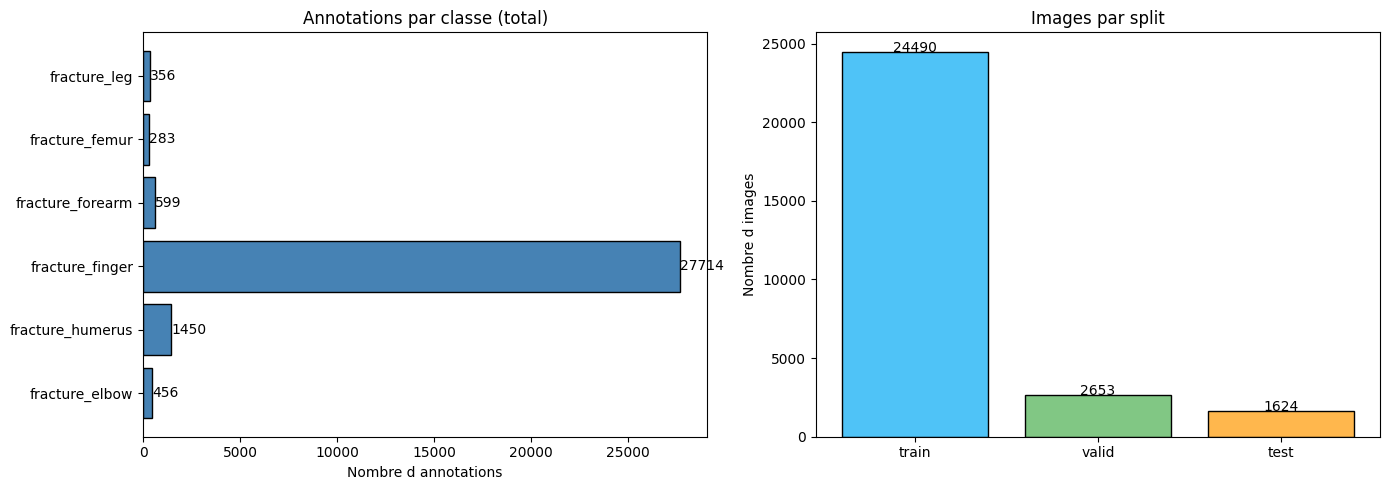

Graphique sauvegarde : /content/distribution_finale.png


In [23]:
# Visualisation de la distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Graphique 1 : annotations par classe ---
cls_ids   = [k for k in sorted(global_counts.keys())]
cls_vals  = [global_counts[k] for k in cls_ids]
cls_lbls  = [CLASS_NAMES[k] for k in cls_ids]

axes[0].barh(cls_lbls, cls_vals, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Nombre d annotations')
axes[0].set_title('Annotations par classe (total)')
for i, v in enumerate(cls_vals):
    axes[0].text(v + 5, i, str(v), va='center')

# --- Graphique 2 : images par split ---
split_vals = [img_counts[s] for s in SPLITS]
axes[1].bar(SPLITS, split_vals, color=['#4FC3F7', '#81C784', '#FFB74D'], edgecolor='black')
axes[1].set_ylabel('Nombre d images')
axes[1].set_title('Images par split')
for i, v in enumerate(split_vals):
    axes[1].text(i, v + 5, str(v), ha='center')

plt.tight_layout()
plt.savefig('/content/distribution_finale.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegarde : /content/distribution_finale.png')

## Etape 12 — Verification d'integrite du dataset

In [25]:
def check_integrity(merged_dir, splits):
    """
    Verifie que chaque image a un fichier label correspondant et que
    les class_id dans les labels sont dans la plage valide.
    """
    n_classes = len(CLASS_NAMES)
    errors = []

    for split in splits:
        img_dir = os.path.join(merged_dir, split, 'images')
        lbl_dir = os.path.join(merged_dir, split, 'labels')

        if not os.path.exists(img_dir):
            continue

        for img_file in os.listdir(img_dir):
            if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            stem = os.path.splitext(img_file)[0]
            lbl_path = os.path.join(lbl_dir, stem + '.txt')

            if not os.path.exists(lbl_path):
                errors.append(f"[{split}] Label manquant pour : {img_file}")
                continue

            with open(lbl_path) as f:
                for ln, line in enumerate(f, 1):
                    parts = line.strip().split()
                    if not parts:
                        continue
                    try:
                        cls_id = int(parts[0])
                    except ValueError:
                        errors.append(f"[{split}] {stem}.txt ligne {ln} : class_id non entier")
                        continue
                    if cls_id < 0 or cls_id >= n_classes:
                        errors.append(f"[{split}] {stem}.txt ligne {ln} : class_id={cls_id} hors plage [0,{n_classes-1}]")
                    if len(parts) < 5:
                        errors.append(f"[{split}] {stem}.txt ligne {ln} : format invalide (< 5 valeurs)")

    return errors


print("Verification d'integrite en cours...")
errors = check_integrity(MERGED_DIR, SPLITS)

if not errors:
    print("Aucune erreur detectee. Dataset valide.")
else:
    print(f"{len(errors)} erreur(s) detectee(s) :")
    for e in errors[:20]:
        print(f"  {e}")
    if len(errors) > 20:
        print(f"  ... et {len(errors) - 20} erreur(s) supplementaire(s)")

Verification d'integrite en cours...
Aucune erreur detectee. Dataset valide.


## Etape 13 — Visualisation d'echantillons avec bounding boxes

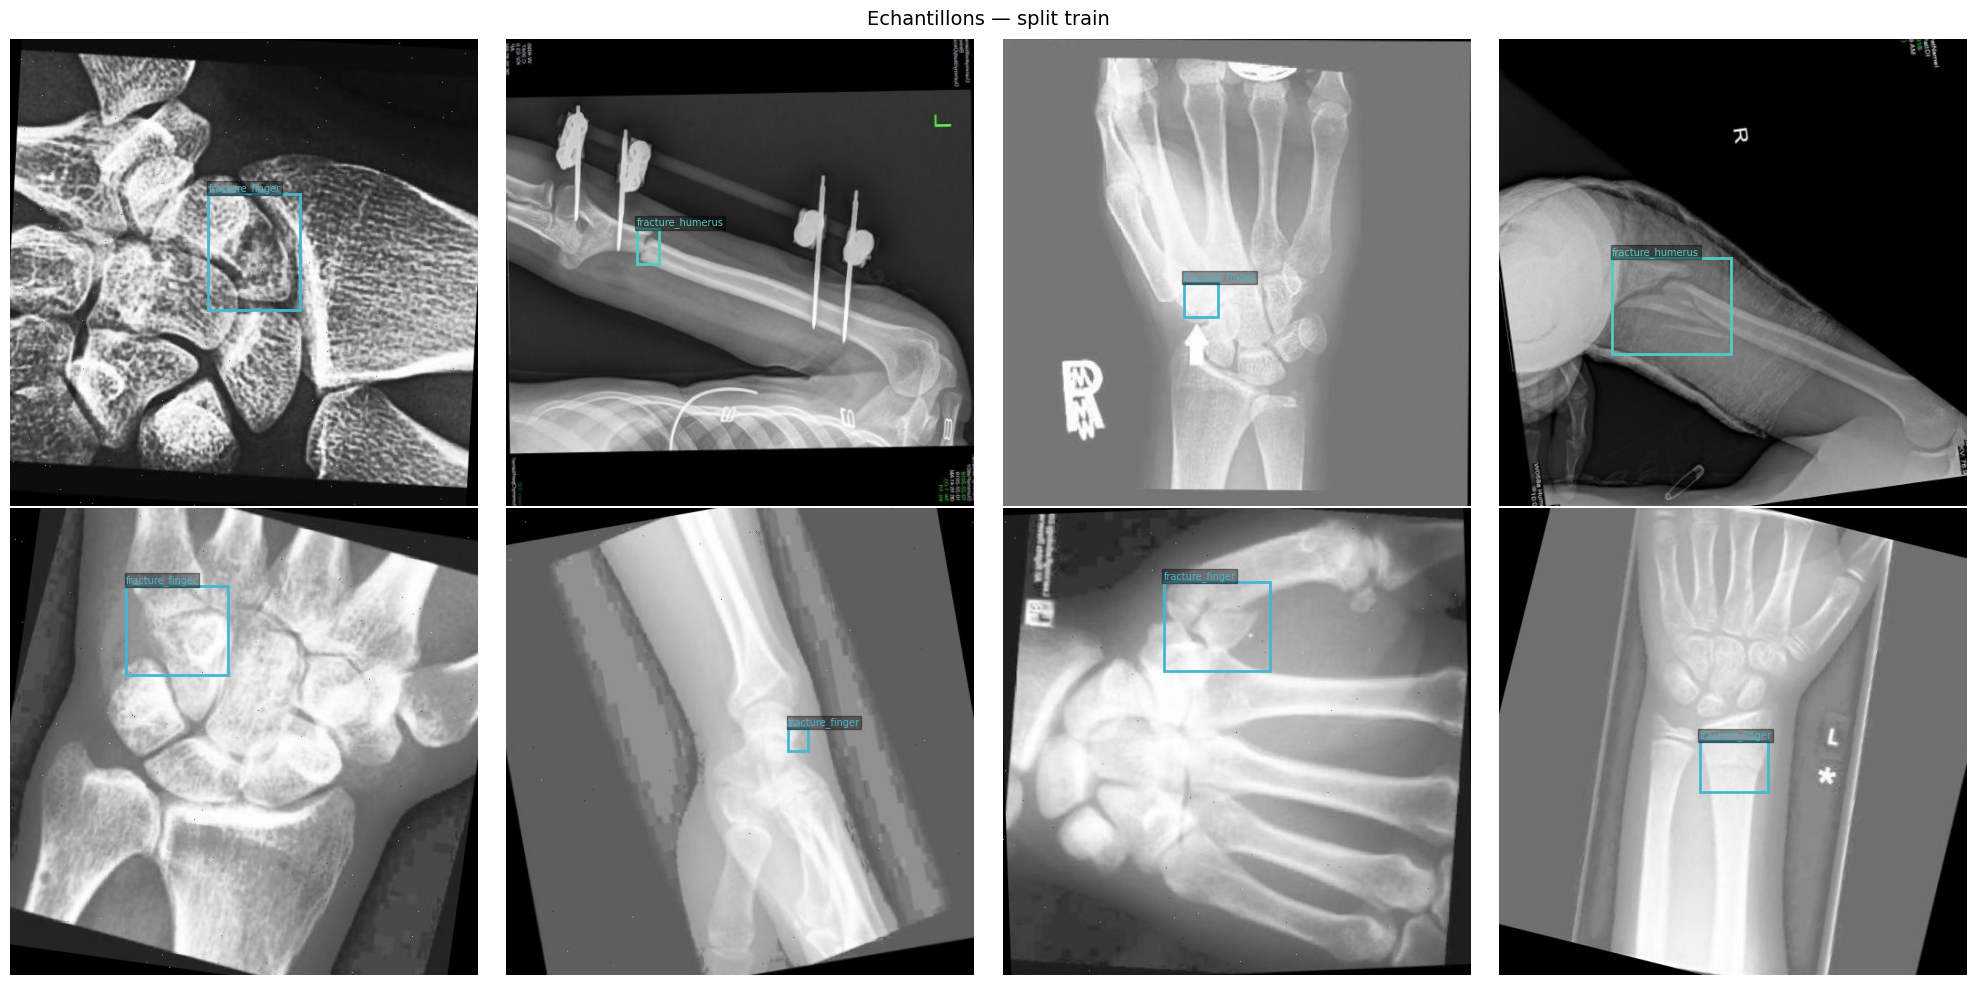

Sauvegarde : /content/samples_train.png


In [26]:
COLORS = [
    '#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4',
    '#FFEAA7', '#DDA0DD', '#98D8C8'
]

def visualize_samples(merged_dir, split='train', n=8):
    img_dir = os.path.join(merged_dir, split, 'images')
    lbl_dir = os.path.join(merged_dir, split, 'labels')

    all_imgs = [f for f in os.listdir(img_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not all_imgs:
        print("Aucune image trouvee.")
        return

    # Privilegier les images avec annotations
    imgs_with_ann = []
    for img_file in all_imgs:
        stem = os.path.splitext(img_file)[0]
        lbl  = os.path.join(lbl_dir, stem + '.txt')
        if os.path.exists(lbl) and os.path.getsize(lbl) > 0:
            imgs_with_ann.append(img_file)

    sample_pool = imgs_with_ann if imgs_with_ann else all_imgs
    sample = random.sample(sample_pool, min(n, len(sample_pool)))

    cols = 4
    rows = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = np.array(axes).flatten()

    for ax, img_file in zip(axes, sample):
        img = Image.open(os.path.join(img_dir, img_file)).convert('RGB')
        W, H = img.size
        ax.imshow(img)
        ax.axis('off')

        stem = os.path.splitext(img_file)[0]
        lbl_path = os.path.join(lbl_dir, stem + '.txt')
        if os.path.exists(lbl_path):
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls_id = int(parts[0])
                    cx, cy, bw, bh = map(float, parts[1:5])
                    color = COLORS[cls_id % len(COLORS)]
                    rect = patches.Rectangle(
                        ((cx - bw/2) * W, (cy - bh/2) * H),
                        bw * W, bh * H,
                        linewidth=2, edgecolor=color, facecolor='none'
                    )
                    ax.add_patch(rect)
                    ax.text(
                        (cx - bw/2) * W, (cy - bh/2) * H - 4,
                        CLASS_NAMES[cls_id], color=color, fontsize=7,
                        bbox=dict(facecolor='black', alpha=0.4, pad=1)
                    )

    # Masquer les axes vides
    for ax in axes[len(sample):]:
        ax.axis('off')

    plt.suptitle(f'Echantillons — split {split}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'/content/samples_{split}.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Sauvegarde : /content/samples_{split}.png')


visualize_samples(MERGED_DIR, split='train', n=8)

Images normales trouvees dans train : 2356


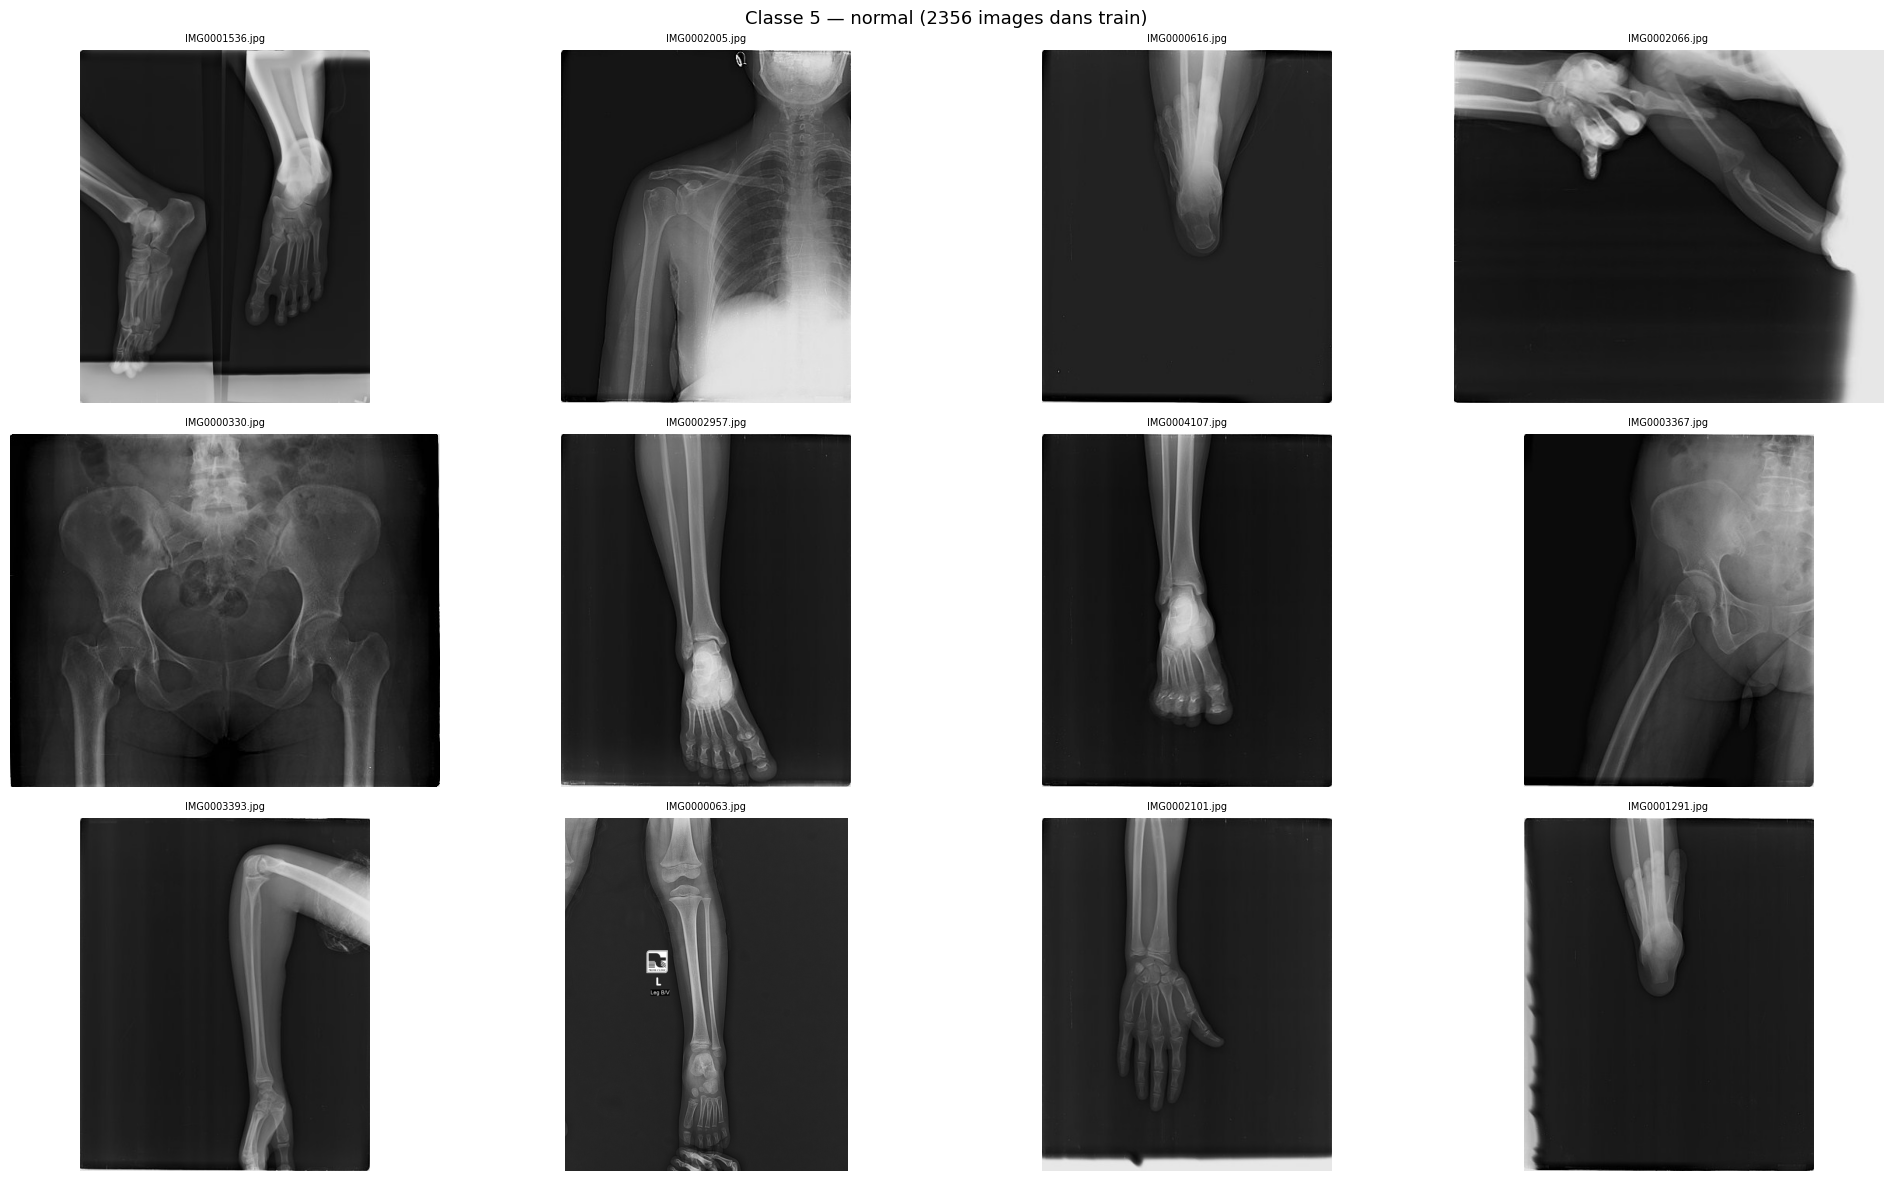

Sauvegarde : /content/samples_normal.png


In [30]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os
import glob

def visualize_normal_samples(merged_dir, n=12):
    """
    Affiche des echantillons de la classe normale (labels vides, prefixe fracatlas).
    """
    img_dir = os.path.join(merged_dir, 'train', 'images')
    lbl_dir = os.path.join(merged_dir, 'train', 'labels')

    # Recuperer uniquement les images fracatlas avec label vide
    normal_imgs = []
    for lbl_path in glob.glob(lbl_dir + '/fracatlas_*.txt'):
        if os.path.getsize(lbl_path) == 0:
            stem     = os.path.splitext(os.path.basename(lbl_path))[0]
            img_path = os.path.join(img_dir, stem + '.jpg')
            if not os.path.exists(img_path):
                img_path = os.path.join(img_dir, stem + '.png')
            if os.path.exists(img_path):
                normal_imgs.append(img_path)

    print(f"Images normales trouvees dans train : {len(normal_imgs)}")

    if not normal_imgs:
        print("Aucune image normale trouvee.")
        return

    sample = random.sample(normal_imgs, min(n, len(normal_imgs)))

    cols = 4
    rows = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()

    for ax, img_path in zip(axes, sample):
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img)
        ax.set_title(
            os.path.basename(img_path).replace('fracatlas_', ''),
            fontsize=7
        )
        ax.axis('off')

    for ax in axes[len(sample):]:
        ax.axis('off')

    fig.suptitle(f'Classe 5 — normal ({len(normal_imgs)} images dans train)', fontsize=13)
    plt.tight_layout()
    plt.savefig('/content/samples_normal.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("Sauvegarde : /content/samples_normal.png")


visualize_normal_samples(MERGED_DIR, n=12)

## Etape 14 — Sauvegarde sur Google Drive

In [31]:
from google.colab import drive

drive.mount('/content/drive')
print("Google Drive monte")

Mounted at /content/drive
Google Drive monte


In [34]:
import subprocess
from google.colab import drive
import shutil
import os

# Monter Drive si pas encore fait
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
    print("Drive monte")
else:
    print("Drive deja monte")

# Verifier la taille avant compression
result = subprocess.run(['du', '-sh', MERGED_DIR], capture_output=True, text=True)
print(f"Taille du dataset : {result.stdout.split()[0]}")

# Compression
ZIP_PATH = '/content/fracture_research_dataset'
print("\nCompression en cours...")
shutil.make_archive(ZIP_PATH, 'zip', MERGED_DIR)

zip_size = os.path.getsize(ZIP_PATH + '.zip') / (1024 ** 3)
print(f"Zip cree : {ZIP_PATH}.zip ({zip_size:.2f} GB)")

# Copie vers Drive
DRIVE_ZIP = '/content/drive/MyDrive/fracture_research_dataset.zip'

if os.path.exists(DRIVE_ZIP):
    os.remove(DRIVE_ZIP)
    print("Ancienne version supprimee")

print("Copie vers Drive en cours...")
shutil.copy(ZIP_PATH + '.zip', DRIVE_ZIP)

print("\nSauvegarde terminee")
print(f"Fichier disponible : {DRIVE_ZIP}")
print(f"Taille finale      : {os.path.getsize(DRIVE_ZIP) / (1024**3):.2f} GB")

Drive deja monte
Taille du dataset : 1.1G

Compression en cours...
Zip cree : /content/fracture_research_dataset.zip (0.86 GB)
Copie vers Drive en cours...

Sauvegarde terminee
Fichier disponible : /content/drive/MyDrive/fracture_research_dataset.zip
Taille finale      : 0.86 GB


In [35]:
import os

DRIVE_ZIP = '/content/drive/MyDrive/fracture_research_dataset.zip'

if os.path.exists(DRIVE_ZIP):
    size_gb = os.path.getsize(DRIVE_ZIP) / (1024 ** 3)
    print(f"Le fichier existe : {DRIVE_ZIP}")
    print(f"Taille            : {size_gb:.2f} GB")
else:
    print("Fichier introuvable sur Drive.")

Le fichier existe : /content/drive/MyDrive/fracture_research_dataset.zip
Taille            : 0.86 GB


In [36]:
for item in sorted(os.listdir('/content/drive/MyDrive')):
    print(item)


Colab Notebooks
fracture_analysis.ipynb
fracture_research_dataset
fracture_research_dataset.zip


In [37]:
from google.colab import files
files.download('/content/drive/MyDrive/fracture_research_dataset.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>